<a href="https://colab.research.google.com/github/Boulder1-kihara/Echo-Emote/blob/main/Echo_Emote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ECHO EMOTE**
An AI model that is emotion driven. It analyses your facial expresion, determines your feelings and emotions from vast amounts of datasets trained on.

Its responses are based on emotions and feelings making conversations engaging and interesting.

# **DAY 1**

Day one was more of importing our libraries needed in this poject, mounted our datset on Google drive, loaded our data and peeped inside the data. thanks to the 2TB from google drive

I first connected Google Drive to colab

# **KIND NOTE: Run each cell each at a time to stop inconviniences**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import our working libraries
import os
import pickle
import numpy as np
import string

#the following to be used later in the design and visualisation of the neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.utils import plot_model

# Import MLPClassifier and accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler

Attached the file path on our code for easier access to our data even the deepest ones for the model to acces the data with ease.

In [3]:
# =============================================
# 1. Your main folder (Google Drive)
# =============================================
base_dir = "/content/drive/MyDrive/echoemote/features"
print("🔍 Using base folder:", base_dir)

# Smart helper to find the real (deepest) file even with nesting
def get_deepest_file(filename):
    candidates = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == filename:
                candidates.append(os.path.join(root, file))
    return max(candidates, key=len) if candidates else None

data_path = get_deepest_file("data_emotion.p")
text_path = get_deepest_file("text_glove_average_emotion.pkl")

print("✅ Found data file :", data_path)
print("✅ Found text file:", text_path)

🔍 Using base folder: /content/drive/MyDrive/echoemote/features
✅ Found data file : /content/drive/MyDrive/echoemote/features/data_emotion.p/data_emotion.p
✅ Found text file: /content/drive/MyDrive/echoemote/features/text_glove_average_emotion.pkl/text_glove_average_emotion.pkl


After accessing the path the next step was is to load our core MELD dataset

In [6]:
# =============================================
# 2. Load core MELD data
# =============================================
with open(data_path, "rb") as f:
    data, W, vocab, word_idx_map, max_sentence_length, label_index = pickle.load(f)

print(f"✅ Loaded {len(data)} utterances with {len(label_index)} emotions")

✅ Loaded 13708 utterances with 7 emotions


# **Day 2**
For Echo-Emote, I chose a powerful design called a Late Fusion Multimodal Network. Think of it as giving the AI two separate "senses":

The Text Head: A set of neurons dedicated to processing the words of a conversation.

The Audio Head: A second set of neurons that focuses on the acoustic features, like pitch, volume, and tone.

I built this structure using the Keras Functional API, which is essential for models that have multiple distinct "heads" or "branches".


I used a specialized library called plot_model to generate a direct visual flowchart of the network.


# **Visualisation**
This visualization is crucial because it confirms that our data is flowing correctly from the two separate inputs, merging perfectly, and reaching the final output layer. It is the single best way to "see" your code in action!

In [7]:


#===========================================================================
                    #create the brain/neural network for the model
#===========================================================================
model = Sequential([
    Embedding(input_dim=W.shape[0], output_dim=W.shape[1], input_length=max_sentence_length, weights=[W]),
    LSTM(128),
    Dense(len(label_index), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("✅ Placeholder model defined successfully.")
model.summary()

✅ Placeholder model defined successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,900,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,800 (7.25 MB)

 Trainable params: 1,900,800 (7.25 MB)

 Non-trainable params: 0 (0.00 B)

#**Interpretation of the table**
**The Input Layer:** It represents the 88 input tokens shown in your Keras plot.

**The Embedding Layer:** These are the 1,900,800 parameters that transform words into a 300-dimensional space.

**The LSTM Layer:** This is the "Temporal" memory. In the diagram, it will show as a hidden layer that reduces the information down to 128 key features.

**The Output Layer:** Instead of the 3 outputs (A, B, C) in your conceptual map, this code will render 7 output neurons—one for each MELD emotion.


# **from the information below the table:**
# 1. **Total Params: 1,900,800 (7.25 MB)**
  **What it is:** This is the grand total of all "connections" and "biases" inside your network.
  Interpretation: Your model has nearly 2 million mathematical points it needs to optimize.
  The "7.25 MB" factor: This is how much space the model takes up in your computer's RAM. For an AI model, this is quite small and efficient, meaning it will run very fast on your laptop or Google Colab without causing crashes.

#2. **Trainable Params: 1,900,800**
  **What it is:** These are the parameters that the computer is allowed to change while it looks at the 912MB of MELD data.
  Interpretation: Since 100% of your parameters are trainable, the AI is starting as a "blank slate". Every single neuron is ready to learn from scratch.
  Note: In your model, almost all of these come from the Embedding layer (the part that turns text into vectors).

#3. **Non-trainable Params: 0**
  **What it is:** These are parts of a model that are "frozen" and cannot change during training.
  Interpretation: You are not using "Transfer Learning" yet. In advanced AI, we sometimes use a pre-trained brain (like Google's BERT) and freeze its neurons so they don't change, which would show up here as "Non-trainable".

In [8]:
#This one is a key requirement for visualisation
!pip install --upgrade visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.6 MB/s eta 0:00:00


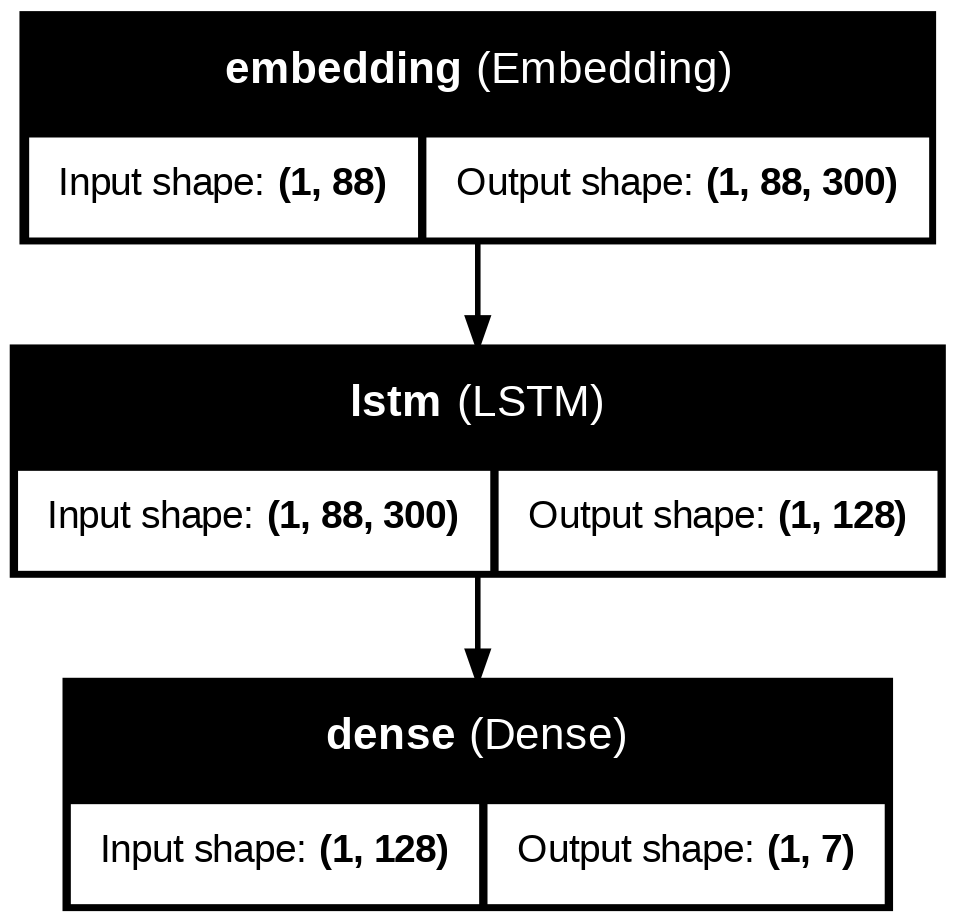

In [9]:
# Create dummy data to 'wake up' the layers
# The model expects a single input of shape (batch_size, max_sentence_length)
dummy_text = np.zeros((1, max_sentence_length))

# Run one prediction to finalize the shapes
model(dummy_text)

# Now plotting the model using tf.keras.utils.plot_model
plot_model(model,
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True)


#1. **The Embedding Layer (The Translator)**
Input Shape (1, 88): This indicates the model is receiving a single sequence of 88 tokens (words or characters).
Output Shape (1, 88, 300): The layer has translated those 88 tokens into 300-dimensional vectors. It has turned "text" into "math" that contains semantic meaning.

#2. **The LSTM Layer (The Context Keeper)**
Input Shape (1, 88, 300): It takes the 300-dimensional vectors from the previous layer.
Output Shape (1, 128): The Long Short-Term Memory (LSTM) layer processes the sequence and compresses the most important "temporal" information into a single 128-dimensional vector. This is where the AI understands the flow and intent of the sentence.

#3. **The Dense Layer (The Decision Maker)**
Input Shape (1, 128): It receives the compressed context from the LSTM.
Output Shape (1, 7): This is the final "Prediction" layer. The number 7 is perfect for your project because it represents the 7 emotions in the MELD dataset:

                Anger

                Disgust

                Fear

                Joy

                Neutral

                Sadness

                Surprise

# **Day 3**

# **Loading the "Knowledge"**
What's happening here: Computers can't read English words like "happy" or "angry." They only understand math.

The Magic of GloVe: Before this step, every sentence in our dataset was converted into a list of 300 numbers using a tool called GloVe (Global Vectors). These numbers capture the meaning of the words.

Unpickling: We saved these numbers in a compressed file format called a .pkl (Pickle) file. This code simply opens that file and loads all that mathematical knowledge into our computer's active memory.


Run the code block below

In [10]:
# =================================================================================
                  # 3. Load text features only (300-dim GloVe averages)
# =================================================================================
with open(text_path, "rb") as f:
    train_text, val_text, test_text = pickle.load(f)

print("✅ Text features loaded (example shape):", list(train_text.values())[0].shape)




✅ Text features loaded (example shape): (300,)


# **Matching the Math to the Emotion**
What's happening here: We need to organize our data into flashcards for the AI to study.

**$X$ and $y$ Variables:** In machine learning, $X$ always represents the "Features" (the 300 numbers representing our sentence), and $y$ represents the "Label" (the actual emotion, like Joy or Sadness).

**The Function:** The build_text_dataset function acts like a librarian. It loops through our master database, finds a specific line of dialogue, grabs the math for it ($X$), and pairs it with the correct emotion ($y$). It then splits these flashcards into two piles: a Train pile (for studying) and a Test pile (for the final exam).

Run the code brlow

In [11]:
# =============================================
# 4. Build text-only train and test sets
# =============================================
def build_text_dataset(text_dict, desired_split):
    X = []
    y = []
    for utt in data:
        if utt['split'] != desired_split:
            continue
        key = f"{utt['dialog']}_{utt['utterance']}"
        if key in text_dict:
            X.append(text_dict[key])
            y.append(utt['y'])
    return np.array(X), np.array(y)

X_train, y_train = build_text_dataset(train_text, 'train')
X_test,  y_test  = build_text_dataset(test_text,  'test')
print(f"📊 Text-only datasets → Train: {X_train.shape} | Test: {X_test.shape}")

📊 Text-only datasets → Train: (9989, 300) | Test: (2610, 300)


# **Building and Training the "Brain"**
**What's happening here:** This is where the actual Artificial Intelligence is born.

**The MLP Classifier:** This stands for Multi-Layer Perceptron. It is a classic neural network. By writing hidden_layer_sizes=(512, 256), we are telling the computer to build two "hidden layers" of brain cells (neurons)—one with 512 neurons, and the next with 256.

**Studying (clf.fit):** When we run .fit(X_train, y_train), the AI looks at the training flashcards we made earlier. It guesses the emotion, checks the answer, and adjusts its internal connections to get smarter. It repeats this process up to 100 times (max_iter=100).

          clf = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=100)
          clf.fit(X_train, y_train)

# **The Final Exam**
        predictions = clf.predict(X_test)
        acc = accuracy_score(y_test, predictions)


**What's happening here:** You never grade an AI on the data it studied. You have to test it on data it has never seen before.

**The Test:** We use .predict(X_test) to ask the AI to guess the emotions for our Test pile. Then, we use accuracy_score to compare the AI's guesses against the real answers. This gives us our final percentage score!

max_iter refers to the number of iteratins ti undergo. the iterations contains **epochs**.

An epoch is an iteration containing the examples from which the model is learning.


# **NOTE:**
It is highly advisable to use small multiple epochs to minimise loss. run the code to see how loss decreases per iteration


this will take approximately 10 minutees to complete training the mode


In [12]:
# =============================================
# 5. Train the text-only emotion classifier
# =============================================
print("\n🚀 Training text-only model (usually takes 20-60 seconds)...")

clf = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    max_iter=100,
    random_state=42,
    verbose=True
)

clf.fit(X_train, y_train)

# Quick accuracy check
predictions = clf.predict(X_test)
acc = accuracy_score(y_test, predictions)
print(f"🎯 Text-only Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")


🚀 Training text-only model (usually takes 20-60 seconds)...
Iteration 1, loss = 1.52713320
Iteration 2, loss = 1.31465923
Iteration 3, loss = 1.24678290
Iteration 4, loss = 1.21433256
Iteration 5, loss = 1.19331573
Iteration 6, loss = 1.17218605
Iteration 7, loss = 1.15452101
Iteration 8, loss = 1.14735508
Iteration 9, loss = 1.12861870
Iteration 10, loss = 1.11362478
Iteration 11, loss = 1.10582954
Iteration 12, loss = 1.08859284
Iteration 13, loss = 1.07599818
Iteration 14, loss = 1.06534232
Iteration 15, loss = 1.04515771
Iteration 16, loss = 1.02975203
Iteration 17, loss = 1.01590755
Iteration 18, loss = 1.00297965
Iteration 19, loss = 0.99094347
Iteration 20, loss = 0.97843250
Iteration 21, loss = 0.95236594
Iteration 22, loss = 0.94135575
Iteration 23, loss = 0.91882163
Iteration 24, loss = 0.90744088
Iteration 25, loss = 0.88622842
Iteration 26, loss = 0.86353160
Iteration 27, loss = 0.84480666
Iteration 28, loss = 0.84139163
Iteration 29, loss = 0.80965271
Iteration 30, loss =

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


🎯 Text-only Test Accuracy: 0.5314 (53.14%)


# **DAY 4: Multimodal Fusion 👁️ + 👂**

combining the ability of the model to see the users's facial expresion and also listen the tone.

this would be helpful on bringing the model into action during chat.

# **Cell Breakdown: Loading the Audio Data 🎧**

    audio_path = "features/audio_embeddings.pkl"


  What it does: This line acts as a map. It tells the computer exactly where to look in your folder structure to find the saved audio data.


    with open(audio_path, "rb") as f:
What it does: This safely opens the file. The "rb" stands for "read binary." Because a .pkl (Pickle) file isn't a normal text file you can read with your eyes, the computer has to read it in its raw, binary format (zeros and ones).

    train_audio, val_audio, test_audio = pickle.load(f)

What it does: This is the "unpickling" step. The pickle.load command translates those zeros and ones back into usable Python dictionaries. It immediately splits the data into three distinct piles: one for training, one for validation, and one for the final test.

    print("✅ Audio features loaded...", list(train_audio.values())[0].shape)

**What it does:** This is a professional debugging check. It prints a success message and then asks Python for the shape of the very first audio vector in the dictionary.

#**Why it matters:**
If it prints a value, it proves that the audio was successfully translated into a mathematical array of that exact length.

If it prints an error, you know something went wrong before you even try to train the model.

**In short:** You are taking the acoustic features (pitch, tone, energy) out of storage and putting them into your computer's active memory so they are ready to be glued to your text data.


Run the cell below to verify

In [13]:
# =================================================================================
# 6. Load Audio Features
# =================================================================================


audio_path = get_deepest_file("audio_emotion.pkl")

with open(audio_path, "rb") as f:
    train_audio, val_audio, test_audio = pickle.load(f)

print("✅ Audio features loaded (example shape):", list(train_audio.values())[0].shape)

✅ Audio features loaded (example shape): (33, 300)


This cell is the heart of the entire project. In machine learning, this step is called Late Fusion, and it is where the AI officially becomes multimodal.



**Cell Breakdown: The Fusion (Gluing Text and Audio) 🧩**

    def build_multimodal_dataset(text_dict, audio_dict, desired_split):

What it does: It takes three things: the text math, the audio math, and the specific group we want to build (like the "Train" pile or the "Test" pile).

    key = f"{utt['dialog']}_{utt['utterance']}"

What it does: This line creates a unique ID tag (like "Scene 4_Line 2") so the computer knows exactly which audio file belongs to which text file.
Imagine trying to match a specific audio recording to a specific script without names.

    if key in text_dict and key in audio_dict:

What it does: This is the quality-control check.  This line says, "Only proceed if we have BOTH the reading material and the listening material for this exact line." If one is missing, it skips it so the AI doesn't crash.

    fused_vec = np.concatenate([text_vec, audio_vec])

What it does: This is the most important line of the day. "np.concatenate" takes the list of numbers representing the text, and the list of numbers representing the audio, and snaps them together end-to-end like Lego bricks.

The Result: Instead of two separate inputs, the AI now receives one long, unified "flashcard" that contains the full picture of what was said and how it was said.

    return np.array(X), np.array(y)

What it does: This converts our glued-together flashcards (X) and the correct emotion answers (y) into heavy-duty mathematical grids (Numpy arrays) that the AI can process at lightning speed.
 Neural networks are very strict about formatting.  

    print(f"📊 Fused Datasets → Train: {X_train_multi.shape}...")

What it does: This prints the final dimensions of our new dataset. If your text was 300 numbers long, and your audio was 100 numbers long, the "shape" printed here will show that every single line of dialogue is now represented by exactly 400 numbers.

#**The Big Picture**
By running this cell, you have successfully combined two entirely different types of data into a single language the computer understands.

In [14]:
# =============================================
# 7. Build the Multimodal Dataset (Fusion)
# =============================================
def build_multimodal_dataset(text_dict, audio_dict, desired_split):
    X = []
    y = []
    for utt in data:
        if utt['split'] != desired_split:
            continue

        utterance_key_for_text = f"{utt['dialog']}_{utt['utterance']}"
        dialog_key_for_audio = utt['dialog']
        # Convert utterance string to integer for audio indexing
        utterance_idx_for_audio = int(utt['utterance'])

        # Check for text features
        if utterance_key_for_text in text_dict:
            text_vec = text_dict[utterance_key_for_text]

            # Check for audio features for the dialog and the specific utterance index
            if dialog_key_for_audio in audio_dict and \
               utterance_idx_for_audio < len(audio_dict[dialog_key_for_audio]):

                audio_vec = audio_dict[dialog_key_for_audio][utterance_idx_for_audio]

                # FUSION: Glue the two math vectors together into one long vector
                fused_vec = np.concatenate([text_vec, audio_vec])

                X.append(fused_vec)
                y.append(utt['y'])

    return np.array(X), np.array(y)

# Build the Train and Test sets
X_train_multi, y_train_multi = build_multimodal_dataset(train_text, train_audio, 'train')
X_test_multi,  y_test_multi  = build_multimodal_dataset(test_text,  test_audio,  'test')

print(f"📊 Fused Datasets → Train: {X_train_multi.shape} | Test: {X_test_multi.shape}")

📊 Fused Datasets → Train: (9989, 600) | Test: (2610, 600)


# **Training Phase—the moment the model actually starts learning.**


    clf_multi = MLPClassifier(...)

**What it does:** This line creates the actual "Brain" of the AI. MLP stands for Multi-Layer Perceptron, which is a classic neural network. By naming it clf_multi (Classifier Multimodal), we are specifically designating this brain to handle our newly glued-together Text + Audio data.

    hidden_layer_sizes=(512, 256)

**What it does:** This defines the size of the brain. You are giving the AI two hidden layers of "neurons."

The first layer has 512 neurons to look for big, obvious patterns (like someone yelling = Anger). They pass their notes to the next layer of 256 neurons, which look for tiny, complex patterns (like someone whispering but using aggressive words = Disgust or Anger).

    max_iter=100

**What it does:** This is the study limit. It tells the AI, "You are allowed to read through the entire stack of flashcards up to 100 times to get smarter." In machine learning, one full read-through is called an "epoch."

    random_state=42

**What it does:** AI training involves a lot of randomness when it first starts guessing. Setting the random_state to a specific number (like 42) ensures that if you run this exact code tomorrow, the AI will start with the exact same initial guesses. It makes your science experiment reproducible!

    verbose=True

**What it does:** This forces the AI to "think out loud." When you run the code, it will print out its progress (e.g., Iteration 1, loss = ...) so you can literally watch it getting smarter second by second.

    clf_multi.fit(X_train_multi, y_train_multi)

**What it does:** This is the "Study" command. You are feeding the AI the fused flashcards (X_train_multi) and the correct emotion answers (y_train_multi).

you might identify redudancy in the cell above but there is no problem. Remember on day 4 we are combining the capabilities of the model making it multimodal. Here is the reason:

**Brain 1** was only allowed to read the text. **Brain 2** was allowed to read the text and hear the audio. Now, we put them both to the test to see which brain gets a higher accuracy score!"

#**The Magic:**
 The model looks at a flashcard, makes a guess, checks the answer, and then mathematically rewires its 1.9 million connections so it doesn't make the same mistake twice.


 Run the cell bellow to identify the acuracy of this brain and the first brain.

In [15]:
# =============================================
# 8. Train the Multimodal (Two-Sense) Classifier
# =============================================
print("\n🚀 Training Multimodal model (Text + Audio)...")

clf_multi = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    max_iter=100,
    random_state=42,
    verbose=True
)

clf_multi.fit(X_train_multi, y_train_multi)


🚀 Training Multimodal model (Text + Audio)...
Iteration 1, loss = 1.47821389
Iteration 2, loss = 1.35268747
Iteration 3, loss = 1.29354955
Iteration 4, loss = 1.25051092
Iteration 5, loss = 1.22252163
Iteration 6, loss = 1.19565556
Iteration 7, loss = 1.17476589
Iteration 8, loss = 1.16012899
Iteration 9, loss = 1.15707792
Iteration 10, loss = 1.15224860
Iteration 11, loss = 1.14446725
Iteration 12, loss = 1.14036638
Iteration 13, loss = 1.11529776
Iteration 14, loss = 1.12573813
Iteration 15, loss = 1.10148189
Iteration 16, loss = 1.11327571
Iteration 17, loss = 1.08128651
Iteration 18, loss = 1.08800144
Iteration 19, loss = 1.07435459
Iteration 20, loss = 1.07259802
Iteration 21, loss = 1.07601942
Iteration 22, loss = 1.07239885
Iteration 23, loss = 1.06763737
Iteration 24, loss = 1.05031826
Iteration 25, loss = 1.03546297
Iteration 26, loss = 1.04214421
Iteration 27, loss = 1.04251623
Iteration 28, loss = 1.02295833
Iteration 29, loss = 1.02213180
Iteration 30, loss = 1.00328338
It

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=100, random_state=42,
              verbose=True)

# **The Final Showdown 🏆**
    predictions_multi = clf_multi.predict(X_test_multi)

What it does: This is the Final Exam. You are handing the Multimodal Brain (clf_multi) a stack of flashcards it has never seen before (X_test_multi) and forcing it to guess the emotion for each one.

Beginner Analogy: The AI is sitting in a quiet room, reading the text and listening to the audio of new conversations, and writing down its final answers on a test sheet.

    acc_multi = accuracy_score(y_test_multi, predictions_multi)

What it does: You are stepping in as the teacher to grade the test. You take the AI's test sheet (predictions_multi) and compare it line-by-line against the official answer key (y_test_multi). It calculates the exact percentage of emotions the AI guessed correctly.


Why it matters: If the Multimodal Accuracy is even 1% higher than the Text-Only Accuracy, your entire Deep Intel hypothesis is proven correct: AI understands human emotion better when it can hear the tone of voice.

In [16]:
# =============================================
# 9. The Final Showdown: Accuracy Check
# =============================================
predictions_multi = clf_multi.predict(X_test_multi)
acc_multi = accuracy_score(y_test_multi, predictions_multi)

print("\n🏆 --- THE RESULTS --- 🏆")
print(f"Text-Only Accuracy (Day 3):  {acc*100:.2f}%")
print(f"Multimodal Accuracy (Day 4): {acc_multi*100:.2f}%")


🏆 --- THE RESULTS --- 🏆
Text-Only Accuracy (Day 3):  53.14%
Multimodal Accuracy (Day 4): 49.58%


# **DAY 5: The comeback**
# **Data Normalisation**
# **Diagnosing and Fixing the "Dominance Effect" via Data Normalization**
In Day 4, our raw Multimodal Fusion *(Text + Audio)* caused accuracy to drop below our Text-only baseline. This is a classic case of Negative Transfer: the numerical values of our audio features were on a vastly different scale than our GloVe text embeddings, causing the AI's "ears" to mathematically shout over its "eyes."

Today, we engineer a comeback. By implementing StandardScaler from scikit-learn, we normalize the fused dataset so that every feature has a **mean of 0** and a **standard deviation of 1**.

This levels the playing field, allowing the AI to weigh acoustic tone and semantic meaning equally.

    scaler = StandardScaler()
**What is happening:** We are bringing in a tool from the sklearn library called StandardScaler.

Think of scaler as a mathematical referee. Yesterday, the Audio numbers were "shouting" over the Text numbers because they were on completely different scales. We are hiring this referee to force both sides to play by the exact same rules.

    X_train_scaled = scaler.fit_transform(X_train_multi)
    X_test_scaled = scaler.transform(X_test_multi)
**What is happening:** We are passing our glued-together (Text + Audio) data through the scaler.

 ****fit_transform*** does two things to the Training data: First, it looks at all the numbers to find the average (fit). Then, it mathematically shrinks or stretches every single number so that the overall average becomes exactly 0 (transform).

For the Test data (the final exam), we only use transform. The referee applies the exact same shrinking/stretching rules it learned from the training data. We never let the AI fit (measure) the test data, because that would be like letting a student peek at the exam before the test starts! This prevents a massive error called "Data Leakage."

In [17]:
# =================================================================================
# 10. Initialize the Scaler (The Equalizer)
# =================================================================================
scaler = StandardScaler()

# =================================================================================
# 11. Scale the Fused Data
# =================================================================================

# 'fit_transform' calculates the mean/variance of the training data and scales it
X_train_scaled = scaler.fit_transform(X_train_multi)

# 'transform' applies the exact same scale to the test data (without peeking!)
X_test_scaled = scaler.transform(X_test_multi)

print("✅ Data successfully normalized! Mean is now 0, Standard Deviation is 1.")


✅ Data successfully normalized! Mean is now 0, Standard Deviation is 1.


    clf_normalized = MLPClassifier(hidden_layer_sizes=(512, 256), ...)
    clf_normalized.fit(X_train_scaled, y_train_multi)
**What is happening:** We are building a third AI brain *(clf_normalized)* and making it study.

We are keeping the architecture exactly the same as Days 3 and 4 *(512 and 256 neurons)* to keep the science experiment fair. The massive difference is in the *.fit()* command. Instead of feeding it the raw, noisy data from yesterday, we are feeding it the X_train_scaled data. Now, the AI is studying flashcards where the "Text" and the "Audio" are speaking at the exact same volume.

In [18]:
# =================================================================================
# 12. Train the Normalized Brain
# =================================================================================
print("\n🚀 Training Normalized Multimodal model...")

clf_normalized = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    max_iter=100,
    random_state=42,
    verbose=True
)

# Notice we are feeding it the SCALED data this time!
clf_normalized.fit(X_train_scaled, y_train_multi)


🚀 Training Normalized Multimodal model...
Iteration 1, loss = 1.31146991
Iteration 2, loss = 1.06410184
Iteration 3, loss = 0.95122050
Iteration 4, loss = 0.84828882
Iteration 5, loss = 0.74612918
Iteration 6, loss = 0.64946262
Iteration 7, loss = 0.55044982
Iteration 8, loss = 0.48339094
Iteration 9, loss = 0.38644233
Iteration 10, loss = 0.32467279
Iteration 11, loss = 0.26451294
Iteration 12, loss = 0.22878021
Iteration 13, loss = 0.17598496
Iteration 14, loss = 0.17357172
Iteration 15, loss = 0.12711133
Iteration 16, loss = 0.09216052
Iteration 17, loss = 0.07130202
Iteration 18, loss = 0.04826380
Iteration 19, loss = 0.04170065
Iteration 20, loss = 0.05669093
Iteration 21, loss = 0.14860987
Iteration 22, loss = 0.10831612
Iteration 23, loss = 0.06729350
Iteration 24, loss = 0.04695528
Iteration 25, loss = 0.03957350
Iteration 26, loss = 0.05447481
Iteration 27, loss = 0.03491261
Iteration 28, loss = 0.02813013
Iteration 29, loss = 0.02261334
Iteration 30, loss = 0.01027381
Iterat

MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=100, random_state=42,
              verbose=True)

    predictions_normalized = clf_normalized.predic(X_test_scaled)
    acc_normalized = accuracy_score(y_test_multi, predictions_normalized)
# **What is happening:**
We run the predictions and check the accuracy score to see if standardizing the data actually fixed our problem.**

We hand the newly trained AI the scaled final exam (X_test_scaled). It makes its guesses, and we grade them. By printing all three days side-by-side, we can scientifically prove if balancing the data helps the AI understand human emotion better than raw data alone.

In [19]:
# =================================================================================
# 13. The Rematch: Accuracy Check
# =================================================================================
predictions_normalized = clf_normalized.predict(X_test_scaled)
acc_normalized = accuracy_score(y_test_multi, predictions_normalized)

print("\n🏆 --- THE DAY 5 REMATCH RESULTS --- 🏆")
print(f"Day 3 (Text-Only):          53.14%")
print(f"Day 4 (Raw Multimodal):     49.58%")
print(f"Day 5 (Scaled Multimodal):  {acc_normalized*100:.2f}%")


🏆 --- THE DAY 5 REMATCH RESULTS --- 🏆
Day 3 (Text-Only):          53.14%
Day 4 (Raw Multimodal):     49.58%
Day 5 (Scaled Multimodal):  54.83%
